# RFI analysis of 1GHz to 1.5GHz

In [ ]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import json
import pandas as pd
from astropy.convolution import Gaussian1DKernel, convolve


def k(x):
    return x*1000

def M(x):
    return x*1e6

def G(x):
    return x*1e9

## Load the data

In [ ]:
file = '/srv/data/drao-rfi/calibrated/RFInd-calibrated-2026-02-24T10.sigmf-data'
file_2 = '/srv/data/drao-rfi/calibrated/RFInd-calibrated-2026-02-24T20.sigmf-data'
meta = '/srv/data/drao-rfi/calibrated/RFInd-calibrated-2026-02-24T10.sigmf-meta'
data = np.memmap(file, dtype='f4', mode='r')
data_2 = np.memmap(file_2, dtype='f4', mode='r')

with open(meta) as m:
    m = json.load(m)

data = data.reshape(-1, 600000)
data = data + np.abs(np.min(data))

data_2 = data_2.reshape(-1, 600000)
data_2 = data_2 + np.abs(np.min(data_2))

min_f = m['global']['antenna:low_frequency']
max_f = m['global']['antenna:high_frequency']
rate = m['global']['core:sample_rate']
period = 1/ rate
f_resolution = (max_f - min_f) / k(600)

print(f"Min Frequency: {min_f/1e6} MHz")
print(f"Max Frequency: {max_f/1e6} MHz")
print(f"Sample Rate: {rate/1e6} MHz")
print(f"Period: {period} s")
print(f"Frequency Resolution: {f_resolution/1e6} MHz")

def convert_frequency_to_index(f):
    """ Function which converts input frequency in MHz to index,
    Where index 600k = 6 GHz
    index 0 = 20 MHz

    Using inverse of
    f = i*(max_f-min_f)/k(600) + min_f
    """

    min_f = m['global']['antenna:low_frequency']
    max_f = m['global']['antenna:high_frequency']

    return int((f*1e6 - min_f)*k(600)/(max_f-min_f))

def convert_index_to_frequency(i):
    """ Function which converts input index to frequency in MHz,
    Where index 600k = 6 GHz
    index 0 = 20 MHz

    Using
    f = i*(max_f-min_f)/k(600) + min_f
    """

    min_f = m['global']['antenna:low_frequency']
    max_f = m['global']['antenna:high_frequency']   
    return (i*(max_f-min_f)/k(600) + min_f)/1e6

CHORD_range = (convert_frequency_to_index(400), convert_frequency_to_index(800))

Min Frequency: 20.0 MHz
Max Frequency: 6000.0 MHz
Sample Rate: 1.3333333333333332e-06 MHz
Period: 0.75 s
Frequency Resolution: 0.009966666666666665 MHz


### The RFI Monitor cycles peridocially, cut data during the calibration cycle

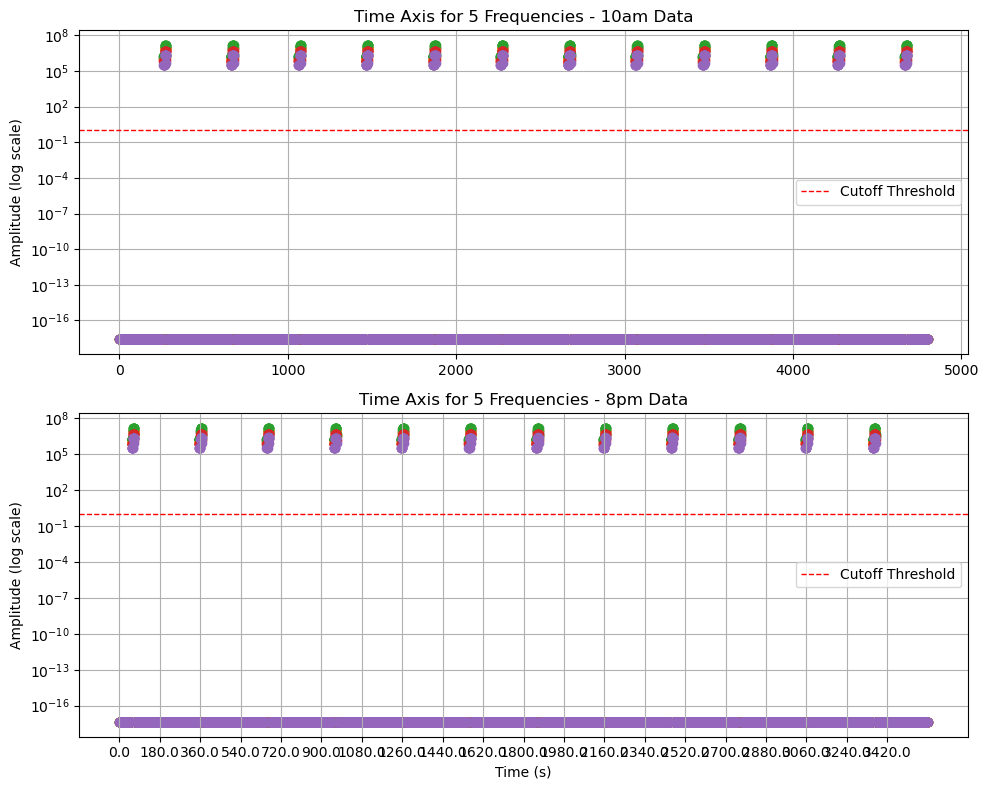

In [4]:
t1 = 0
t2 = 4800

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))

# Top plot - data (10am)
for i in range(100, 600, 100):
    ax1.scatter(np.arange(t1, t2), data[np.arange(t1, t2), k(i)])
ax1.axhline(y=1, color='r', linestyle='--', linewidth=1, label='Cutoff Threshold')
ax1.set_title("Time Axis for 5 Frequencies - 10am Data")
ax1.set_yscale('log')
ax1.set_ylabel("Amplitude (log scale)")
ax1.grid(True)
ax1.legend()

# Bottom plot - data_2 (8pm)
for i in range(100, 600, 100):
    ax2.scatter(np.arange(t1, t2), data_2[t1:t2, k(i)])
ax2.axhline(y=1, color='r', linestyle='--', linewidth=1, label='Cutoff Threshold')
ax2.set_title("Time Axis for 5 Frequencies - 8pm Data")
ax2.set_yscale('log')
ax2.set_xlabel("Time (s)")
tick_idx = np.arange(t1, t2, 240)
ax2.set_xticks(tick_idx)
ax2.set_xticklabels(np.round(tick_idx * period, 1))
ax2.set_ylabel("Amplitude (log scale)")
ax2.grid(True)
ax2.legend()

plt.tight_layout()
plt.show()

data_10am = np.where(data > 1, np.nan, data)
data_10am = np.where(data_10am == 0, np.nan, data_10am)
data_8pm = np.where(data_2 > 1, np.nan, data_2)
data_8pm = np.where(data_8pm == 0, np.nan, data_8pm)


## Compute Baseline across all samples using iterative smoothing

Best to run this one time since it takes a while

In [ ]:
def iterative_baseline(y, bandwith, clip_sigma=3.0, n_iter=10):

    y = np.array(y, dtype=float)
    mask = np.isfinite(y)
    kernel = Gaussian1DKernel(stddev=bandwith)

    for _ in range(n_iter):
        masked = np.where(mask, y, np.nan)
        baseline = convolve(masked, kernel, boundary='extend',
                            nan_treatment='interpolate', normalize_kernel=True)
        residual = y - baseline
        sigma_std = np.nanstd(residual[mask])
        mask = mask & (residual < clip_sigma * sigma_std)

    return baseline

y = np.nanmean(data_10am, axis=0)
baseline = iterative_baseline(y, bandwith=20, clip_sigma=4.0, n_iter=10)

downsample_factor = 10

plt.figure(figsize=(10, 5))
plt.plot(convert_index_to_frequency(np.arange(len(y)//downsample_factor)), y[0:len(y):downsample_factor], label='Mean Spectrum (10am)', color='blue')
plt.plot(convert_index_to_frequency(np.arange(len(baseline)//downsample_factor)), baseline[0:len(baseline):downsample_factor], label='Baseline', color='black', linestyle='--')
plt.title("Mean Spectrum and Baseline - 10am Data")
plt.xlabel("Frequency (MHz)")
plt.ylabel("Amplitude")
plt.legend()

(600000,)

### Create a condensed version of the data for faster ploting

In [5]:
def compress_data(data, min_f, max_f, f_samples=-1, t_samples=4800):

    time_max = data.shape[0] - 1
    time_index_range = np.unique(np.linspace(0, time_max, t_samples).astype(int))
    min_f_index = convert_frequency_to_index(min_f)
    max_f_index = convert_frequency_to_index(max_f)
    if f_samples == -1:
        f_samples = max_f_index - min_f_index + 1 
    freq_i_range = np.unique(np.linspace(min_f_index, max_f_index, f_samples).astype(int))
    freq_range = np.linspace(min_f, max_f, f_samples)

    data_slice = data[np.ix_(time_index_range, freq_i_range)]
    compressed_data = pd.DataFrame({
        "index": freq_i_range, "frequency": freq_range,
        "mean": np.nanmean(data_slice, axis=0),
        "std": np.nanstd(data_slice, axis=0),
        "max": np.nanpercentile(data_slice, 99.9, axis=0),
        "min": np.nanpercentile(data_slice, 0.1, axis=0)
        })
    
    for i in range(1, 21):
        trace = data[time_index_range[(time_max-1)//20 * (i-1)], freq_i_range]
        j = 0
        while np.isnan(trace).any():
            j += 1
            trace = data[time_index_range[(time_max-1)//20 * (i-1) + j], freq_i_range]
        compressed_data[f'trace_{i}'] = trace

    return compressed_data

min_f = 300
max_f = 1500
compressed_data_10am = compress_data(data_10am, min_f, max_f, f_samples=10000)
compressed_data_8pm = compress_data(data_8pm, min_f, max_f, f_samples=10000)
compressed_data_10am.head(2)


,index,frequency,mean,std,max,min,trace_1,trace_2,trace_3,trace_4,...,trace_11,trace_12,trace_13,trace_14,trace_15,trace_16,trace_17,trace_18,trace_19,trace_20
0,28093,300.000000,2.615941e-18,3.451237e-22,2.618599e-18,2.615759e-18,2.615777e-18,2.615828e-18,2.616348e-18,2.615822e-18,...,2.615914e-18,2.615894e-18,2.615903e-18,2.615981e-18,2.615865e-18,2.615940e-18,2.615784e-18,2.619510e-18,2.615914e-18,2.615964e-18
1,28105,300.120012,2.615875e-18,9.169400e-23,2.616250e-18,2.615763e-18,2.616203e-18,2.616047e-18,2.615884e-18,2.615860e-18,...,2.615976e-18,2.615931e-18,2.615907e-18,2.615961e-18,2.615890e-18,2.615870e-18,2.615926e-18,2.615883e-18,2.616043e-18,2.616034e-18


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


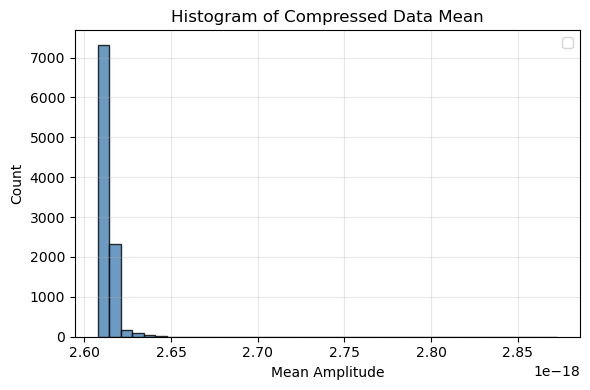

In [6]:
plt.figure(figsize=(6, 4))
plt.hist(compressed_data_10am["mean"], bins=40, color="steelblue", edgecolor="black", alpha=0.8)
#plt.xscale("log")
plt.title("Histogram of Compressed Data Mean")
plt.xlabel("Mean Amplitude")
plt.ylabel("Count")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.legend()
plt.show()

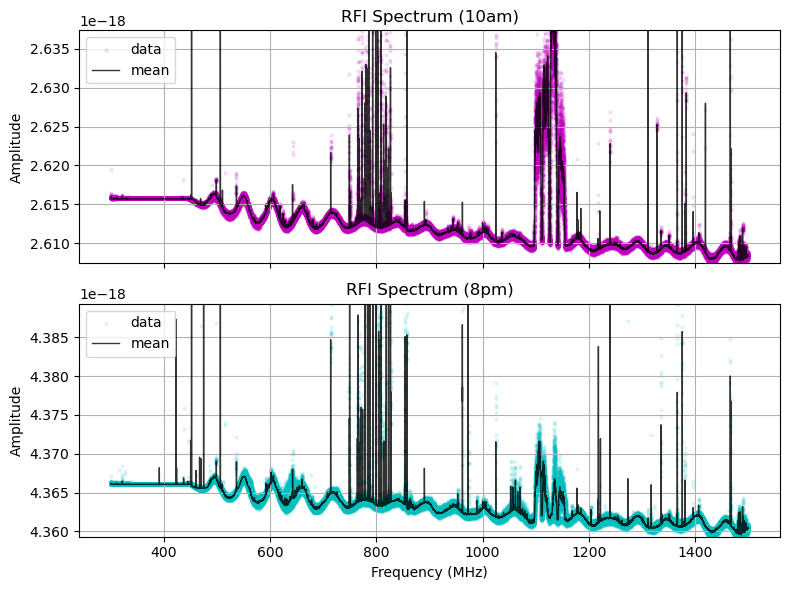

(<Figure size 800x600 with 2 Axes>,
 (<Axes: title={'center': 'RFI Spectrum (10am)'}, ylabel='Amplitude'>,
  <Axes: title={'center': 'RFI Spectrum (8pm)'}, xlabel='Frequency (MHz)', ylabel='Amplitude'>))

In [43]:
def plot_compressed(
    compressed_data,
    title="10am",
    compressed_data_2=None,
    title_2="8pm",
    include_baseline=False,
    include_traces=True,
    include_mean=True,
    y_range=0.03e-18,
    save_path=None,
):
    def _plot_one(ax, df, color, panel_title):

        if include_traces:
            for j in range(1, 20):
                ax.scatter(
                    df["frequency"],
                    df[f"trace_{j}"],
                    c=color,
                    s=4,
                    alpha=0.1,
                    label="data" if j == 1 else None,
                )
        if include_mean:
            ax.plot(
                df["frequency"],
                df["mean"],
                color="black",
                linestyle="-",
                linewidth=1,
                alpha=0.8,
                label="mean",
            )
        if include_baseline:
            ax.plot(
                df["frequency"],
                df["baseline"],
                color="black",
                linestyle="--",
                linewidth=1,
                alpha=1,
                label="baseline",
            )
        
        _min = np.min(df[f"trace_1"])
        ax.set_title(f"RFI Spectrum ({panel_title})")
        ax.set_ylabel("Amplitude")
        ax.set_ylim(_min, _min + y_range)
        ax.grid(True)
        ax.legend()

    if compressed_data_2 is None:
        fig, ax = plt.subplots(1, 1, figsize=(8, 4))
        _plot_one(ax, compressed_data, "m", title)
        ax.set_xlabel("Frequency (MHz)")
        axes = (ax,)
    else:
        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 6), sharex=True)
        _plot_one(ax1, compressed_data, "m", title)
        _plot_one(ax2, compressed_data_2, "c", title_2)
        ax2.set_xlabel("Frequency (MHz)")
        axes = (ax1, ax2)

    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=300)

    plt.show()
    return fig, axes


# Example:
plot_compressed(compressed_data = compressed_data_10am, title="10am", 
                compressed_data_2 = compressed_data_8pm, title_2="8pm",
                y_range=0.03e-18,
                include_baseline=False,
                save_path="../thesis/plots/rfi/full_spectrum_overview.png")


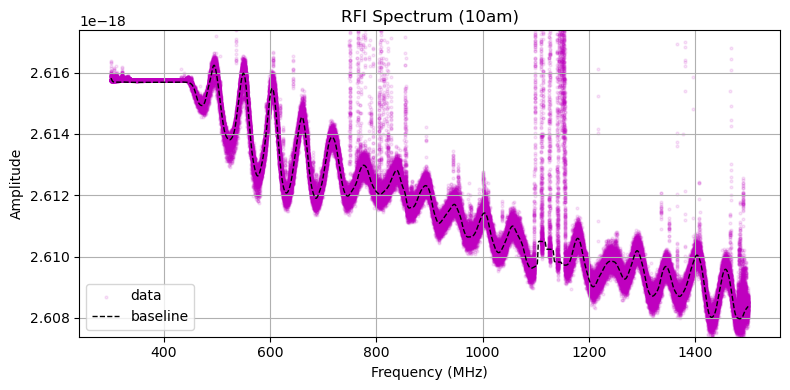

In [44]:
from astropy.convolution import Gaussian1DKernel, convolve

def iterative_baseline(y, bandwith, clip_sigma=3.0, n_iter=10):

    y = np.array(y, dtype=float)
    mask = np.isfinite(y)
    kernel = Gaussian1DKernel(stddev=bandwith)

    for _ in range(n_iter):
        masked = np.where(mask, y, np.nan)
        baseline = convolve(masked, kernel, boundary='extend',
                            nan_treatment='interpolate', normalize_kernel=True)
        residual = y - baseline
        sigma_std = np.nanstd(residual[mask])
        mask = mask & (residual < clip_sigma * sigma_std)

    return baseline


baseline = iterative_baseline(
    compressed_data_10am['mean'].values,
    bandwith=20,
    clip_sigma=4.0,
    n_iter=10
)
compressed_data_10am['baseline'] = baseline
fig, axes = plot_compressed(compressed_data = compressed_data_10am, title="10am", 
                compressed_data_2 = None, title_2="8pm",
                y_range=0.01e-18,
                include_baseline=True,
                include_traces=True,
                include_mean=False,
                save_path=None)


Markdown zoom to a specific line

In [83]:
convert_frequency_to_index(75.50)

5568

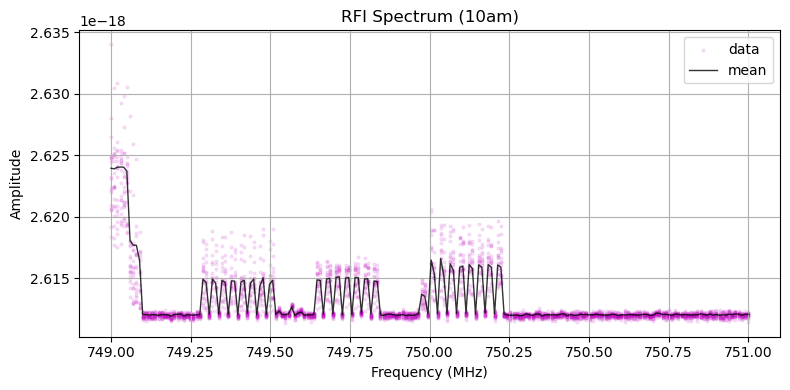

(<Figure size 800x400 with 1 Axes>,
 (<Axes: title={'center': 'RFI Spectrum (10am)'}, xlabel='Frequency (MHz)', ylabel='Amplitude'>,))

In [82]:
plot_compressed(
    compress_data(data_10am, 749, 751)
)

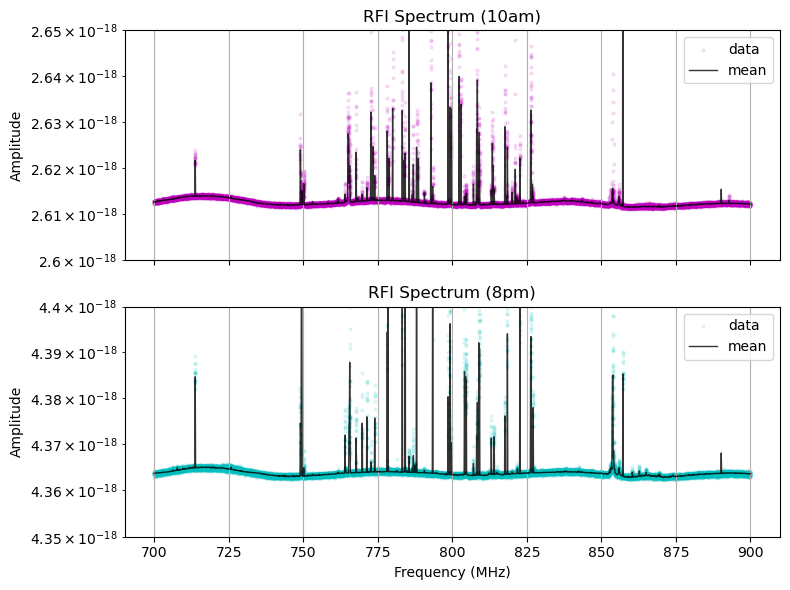

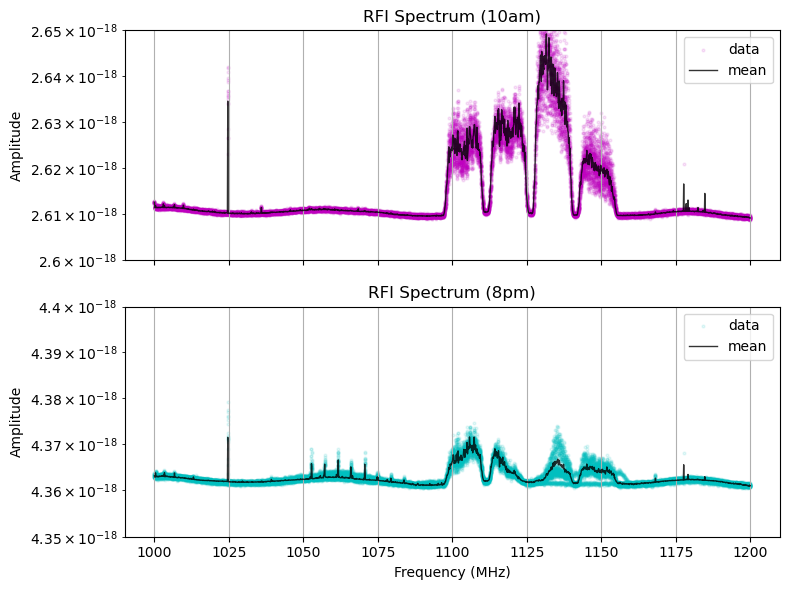

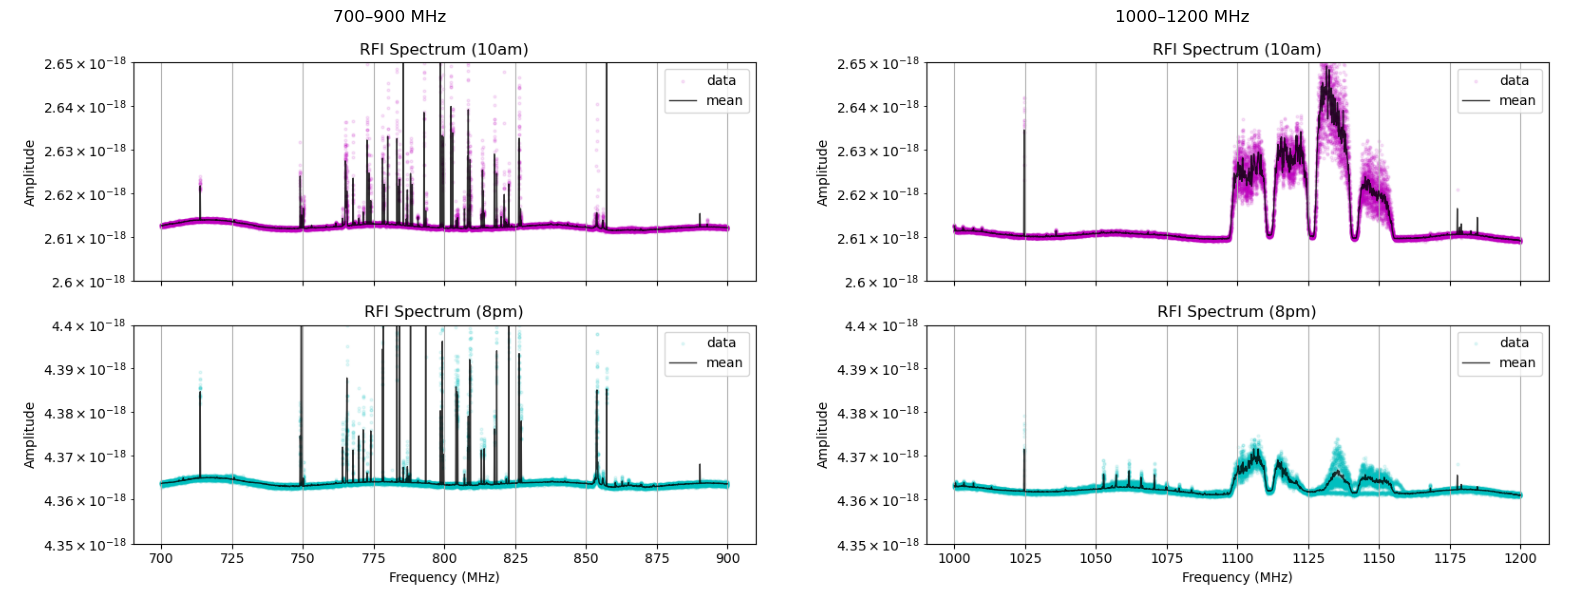

In [40]:
ranges = [(700, 900), (1000, 1200)]

# Build individual figures from your existing function
fig_list = []
for f_1, f_2 in ranges:
    fig_i, _ = plot_full_spectrum_overview(f_1, f_2, save_path=None)
    fig_list.append((fig_i, f_1, f_2))

# Create one combined figure and show each returned fig as an image
fig_side, axes_side = plt.subplots(1, len(fig_list), figsize=(16, 6))
if len(fig_list) == 1:
    axes_side = [axes_side]

for ax, (fig_i, f_1, f_2) in zip(axes_side, fig_list):
    fig_i.canvas.draw()
    w, h = fig_i.canvas.get_width_height()
    img = np.frombuffer(fig_i.canvas.buffer_rgba(), dtype=np.uint8).reshape(h, w, 4)

    ax.imshow(img)
    ax.set_title(f"{f_1}–{f_2} MHz")
    ax.axis("off")

    plt.close(fig_i)  # avoid duplicate standalone display

plt.tight_layout()
plt.savefig("../thesis/plots/rfi/side_by_side_comparison.png", dpi=300)
plt.show()


In [11]:
H_transitions = {
    "H186alpha": 1013.76766452,
    "H185alpha": 1030.25153147,
    "H184alpha": 1047.09471537,
    "H183alpha": 1064.30706038,
    "H182alpha": 1081.89873607,
    "H181alpha": 1099.88025005,
    "H180alpha": 1118.26246118,
    "H179alpha": 1137.05659327,
    "H178alpha": 1156.27424957,
    "H177alpha": 1175.92742772,
    "H176alpha": 1196.02853557,
    "H175alpha": 1216.59040757,
    "H174alpha": 1237.626322,
    "H173alpha": 1259.150019,
    "H172alpha": 1281.1757194,
    "H171alpha": 1303.71814445,
    "H170alpha": 1326.7925365,
    "H169alpha": 1350.41468066,
    "H168alpha": 1374.60092745,
    "H167alpha": 1399.36821658,
    "H166alpha": 1424.73410189,
    "H165alpha": 1450.71677746,
    "H164alpha": 1477.33510502,
}

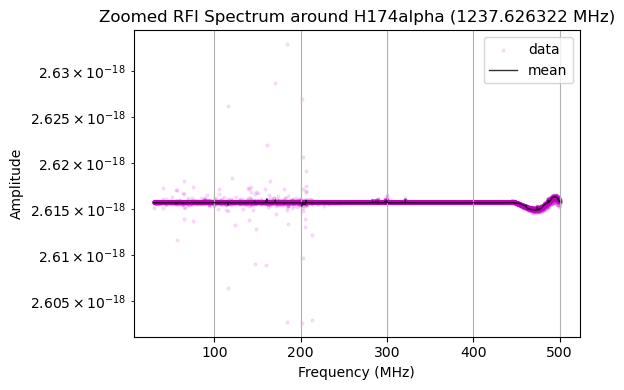

In [47]:
central_freq = H_transitions["H174alpha"]
freq_range = 10 # MHz

zoomed_data = compress_data(data_10am, 30, 500, f_samples=1000)

plt.figure(figsize=(6, 4))
for j in range(1, 20):
    plt.scatter(
        zoomed_data["frequency"],
        zoomed_data[f"trace_{j}"],
        c="m", s=4, alpha=0.1,
        label="data" if j == 1 else None
    )
plt.plot(
    zoomed_data["frequency"],
    zoomed_data["mean"],
    label="mean",
    color="black",
    linestyle="-",
    linewidth=1,
    alpha=0.8
)
plt.title(f"Zoomed RFI Spectrum around H174alpha ({central_freq} MHz)")
plt.xlabel("Frequency (MHz)")
plt.ylabel("Amplitude")
plt.yscale("log")
plt.grid(True)
plt.legend()
plt.tight_layout()

FileNotFoundError: [Errno 2] No such file or directory: 'rrl_images/H186alpha.png'

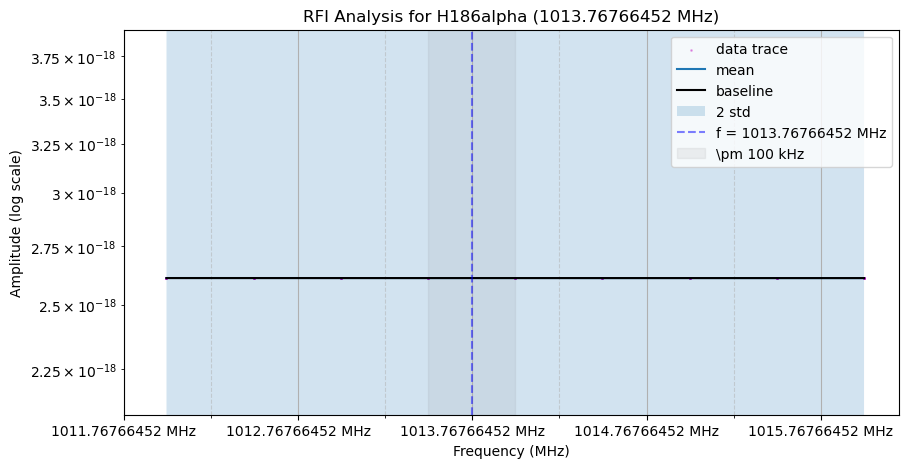

In [44]:

for transition_name, frequency in H_transitions.items():
    f = frequency
    close_range = f - 0.1, f + 0.1
    long_range = f - 2, f + 2

    closest_row = (compressed_data['frequency'] - f).abs().idxmin()
    close_min_row = (compressed_data['frequency'] - close_range[0]).abs().idxmin()
    close_max_row = (compressed_data['frequency'] - close_range[1]).abs().idxmin()
    long_min_row = (compressed_data['frequency'] - long_range[0]).abs().idxmin()
    long_max_row = (compressed_data['frequency'] - long_range[1]).abs().idxmin()

    close_id_range = range(close_min_row, close_max_row + 1)
    long_id_range = range(long_min_row, long_max_row + 1)

    frequency_range = compressed_data.loc[long_id_range, 'frequency']
    baseline = compressed_data.loc[long_id_range, 'baseline'] 
    geo_means = compressed_data.loc[long_id_range, 'mean']
    geo_stds = compressed_data.loc[long_id_range, 'std']

    y_min = np.min(compressed_data.loc[close_id_range][["baseline", "mean", "trace_1", "trace_2", "trace_3"]])*0.8
    y_max = np.max(compressed_data.loc[close_id_range][["baseline", "mean", "trace_1", "trace_2", "trace_3"]])*1.5

    plt.figure(figsize=(10,5))

    # plot a few raw traces
    for j in range(1, 10):
        plt.scatter(
            frequency_range, 
            compressed_data.loc[long_id_range, f'trace_{j}'],
            c='m', s=1, alpha=0.3, 
            label='data trace' if j==1 else None
        )

    # plot mean and ±2σ
    plt.plot(
        frequency_range, 
        geo_means,
        label='mean'
    )

    plt.plot(
        frequency_range, 
        baseline,
        label='baseline',
        color='black'
    )

    plt.fill_between(frequency_range,
                    geo_means/(geo_stds**2),
                    geo_means*(geo_stds**2),
                    alpha=0.2, label='2 std')

    plt.axvline(
        x=f, color='b', alpha=0.5, linestyle='--', label=f'f = {f} MHz')
    plt.axvspan(
        compressed_data.loc[close_min_row, "frequency"],
        compressed_data.loc[close_max_row, "frequency"],
        color='grey', alpha=0.1, label='\pm 100 kHz')


    # Set logarithmic scale for y-axis
    plt.yscale('log')

    # Set major ticks on x-axis at every 1 unit with MHz labels
    major_ticks = np.arange(long_range[0], long_range[1] + 1, 1)
    plt.xticks(ticks=major_ticks, labels=[f"{x} MHz" for x in major_ticks])

    # Enable minor ticks for both axes
    plt.minorticks_on()

    # Set minor ticks on x-axis at every 0.5 units
    minor_ticks = np.arange(long_range[0], long_range[1] + 0.5, 0.5)
    plt.gca().set_xticks(minor_ticks, minor=True)

    # Enable grid for major ticks on x-axis
    plt.grid(visible=True, which='minor', axis='x', linestyle='--', alpha=0.5)
    plt.grid(visible=True, which='major', axis='x')

    plt.legend()
    plt.title("RFI Analysis for " + transition_name + f" ({f} MHz)")
    plt.xlabel("Frequency (MHz)")
    plt.ylabel("Amplitude (log scale)")

    plt.ylim(y_min, y_max)

    plt.savefig(f'rrl_images/{transition_name}.png', dpi=300, bbox_inches='tight')
    plt.show()
